# L2-A - Linear Quantization I: Quantize and De-quantize a Tensor

In this lesson, you will learn the fundamentals of linear quantization.

In [1]:
import torch

## Quantization with Random `Scale` and `Zero Point`

- Implement Linear Quantization for when the "scale" and the "zero point" are known/randomly selected.

In [3]:
def linear_q_with_scale_and_zero_point(tensor, scale, zero_point, dtype=torch.int8):

    scaled_and_shifted_tensor = tensor / scale + zero_point

    rounded_tensor = torch.round(scaled_and_shifted_tensor)

    q_min = torch.iinfo(dtype).min
    q_max = torch.iinfo(dtype).max

    q_tensor = rounded_tensor.clamp(q_min, q_max).to(dtype)

    return q_tensor

In [4]:
### a dummy tensor to test the implementation
test_tensor = torch.tensor([[191.6, -13.5, 728.6], [92.14, 295.5, -184], [0, 684.6, 245.5]])

In [5]:
### these are random values for "scale" and "zero_point"
### to test the implementation
scale = 3.5
zero_point = -70

In [6]:
quantized_tensor = linear_q_with_scale_and_zero_point(test_tensor, scale, zero_point)

In [7]:
quantized_tensor

tensor([[ -15,  -74,  127],
        [ -44,   14, -123],
        [ -70,  126,    0]], dtype=torch.int8)

## Dequantization with Random `Scale` and `Zero Point`

- Now, Dequantize the tensor to see how precise the quantization is.

In [11]:
dequantized_tensor = scale * (quantized_tensor.float() - zero_point)

In [12]:
# the original tensor
print(test_tensor.numpy())

[[ 191.6   -13.5   728.6 ]
 [  92.14  295.5  -184.  ]
 [   0.    684.6   245.5 ]]


In [13]:
dequantized_tensor

tensor([[ 192.5000,  -14.0000,  689.5000],
        [  91.0000,  294.0000, -185.5000],
        [   0.0000,  686.0000,  245.0000]])

In [14]:
### without casting to float ==> need to cast
scale * (quantized_tensor - zero_point)

tensor([[ 192.5000,  -14.0000, -206.5000],
        [  91.0000,  294.0000, -185.5000],
        [   0.0000, -210.0000,  245.0000]])

In [16]:
def linear_dequantization(quantized_tensor, scale, zero_point):
    return scale * (quantized_tensor.float() - zero_point)

- Calculate `dequantized_tensor` using the function `linear_dequantization`.

In [17]:
dequantized_tensor = linear_dequantization(quantized_tensor, scale, zero_point)

- Print the results of the `dequantized_tensor`.

In [18]:
dequantized_tensor

tensor([[ 192.5000,  -14.0000,  689.5000],
        [  91.0000,  294.0000, -185.5000],
        [   0.0000,  686.0000,  245.0000]])

### Quantization Error

- Load the `plot_quantization_errors` from the helper file.
- To access the `helper.py` file, you can click `File --> Open...`, on the top left.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from matplotlib.colors import ListedColormap


def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=None):
    """
    Plot a heatmap of tensors using seaborn
    """
    sns.heatmap(tensor.cpu().numpy(), ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, annot=True, fmt=".2f", cbar=False)
    ax.set_title(title)
    ax.set_yticklabels([])
    ax.set_xticklabels([])


def plot_quantization_errors(original_tensor, quantized_tensor, dequantized_tensor, dtype=torch.int8, n_bits=8):
    """
    A method that plots 4 matrices, the original tensor, the quantized tensor
    the de-quantized tensor and the error tensor.
    """
    # Get a figure of 4 plots
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    # Plot the first matrix
    plot_matrix(original_tensor, axes[0], "Original Tensor", cmap=ListedColormap(["white"]))

    # Get the quantization range and plot the quantized tensor
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    plot_matrix(
        quantized_tensor, axes[1], f"{n_bits}-bit Linear Quantized Tensor", vmin=q_min, vmax=q_max, cmap="coolwarm"
    )

    # Plot the de-quantized tensors
    plot_matrix(dequantized_tensor, axes[2], "Dequantized Tensor", cmap="coolwarm")

    # Get the quantization errors
    q_error_tensor = abs(original_tensor - dequantized_tensor)
    plot_matrix(q_error_tensor, axes[3], "Quantization Error Tensor", cmap=ListedColormap(["white"]))

    fig.tight_layout()
    plt.show()

- Plot the quantization results.

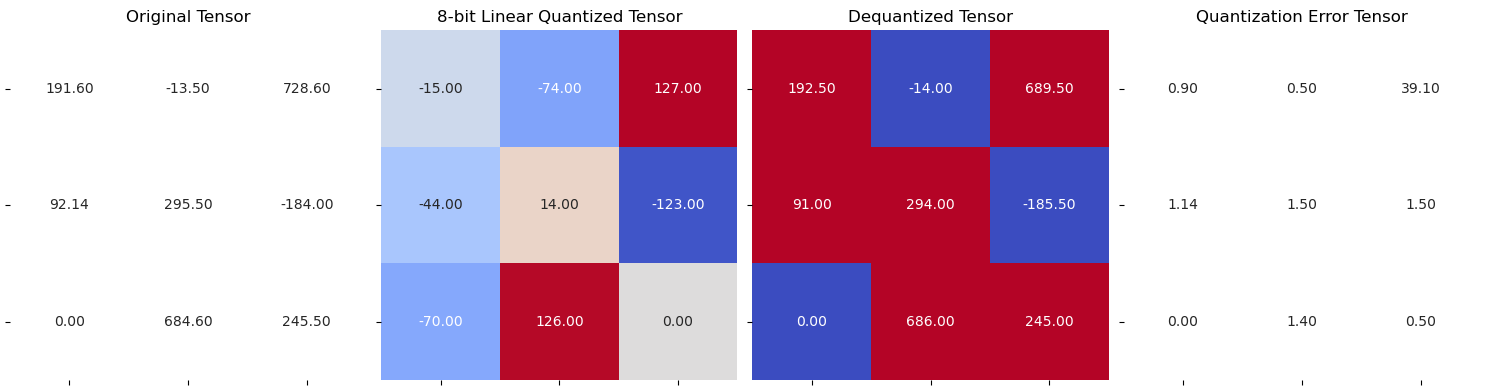

In [22]:
plot_quantization_errors(test_tensor, quantized_tensor, dequantized_tensor)

**Note:** For the plot above, `Quantization Error Tensor = abs(Original Tensor - Dequantized Tensor)`

- Calculate an "overall" quantization error by using [Mean Squared Error](https://en.wikipedia.org/wiki/Mean_squared_error) technique.

In [26]:
dequantized_tensor - test_tensor

tensor([[  0.9000,  -0.5000, -39.1000],
        [ -1.1400,  -1.5000,  -1.5000],
        [  0.0000,   1.4000,  -0.5000]])

In [27]:
(dequantized_tensor - test_tensor).square()

tensor([[8.0999e-01, 2.5000e-01, 1.5288e+03],
        [1.2996e+00, 2.2500e+00, 2.2500e+00],
        [0.0000e+00, 1.9601e+00, 2.5000e-01]])

In [28]:
(dequantized_tensor - test_tensor).square().mean()

tensor(170.8753)